# Single-friend semi-Brukner extended Wigner's friend scenario

In [1]:
from typing import Optional
import itertools
import functools
import random
import numpy as np
import math
import matplotlib.pyplot as plt

from collections import defaultdict
from enum import Enum
from mitiq import zne

import qiskit
from qiskit_aer.noise import NoiseModel, depolarizing_error, amplitude_damping_error
from qiskit.providers import Backend
from qiskit.providers import fake_provider
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister

## Configurational settings

In [2]:
class Setting(Enum):
    PEEK = 1
    REVERSE_1 = 2
    REVERSE_2 = 3
    
class Observer(Enum):
    ALICE = 0
    BOB = 1

In [3]:
# Experiment settings (peek, reverse_1, and reverse_2).
PEEK = Setting.PEEK.value
REVERSE_1 = Setting.REVERSE_1.value
REVERSE_2 = Setting.REVERSE_2.value
SETTINGS = [PEEK, REVERSE_1, REVERSE_2]

# "Super"-observers (Alice and Bob).
ALICE = Observer.ALICE.value
BOB = Observer.BOB.value
OBSERVERS = [ALICE, BOB]

# Angles and beta term used for Alice and Bob measurement operators from arXiv:1907.05607.
# Note that despite the fact that degrees are used, we need to convert this to radians.
ANGLES = {PEEK: np.deg2rad(168), REVERSE_1: np.deg2rad(0), REVERSE_2: np.deg2rad(118)}
BETA = np.deg2rad(175)

## EWFS circuit

In [4]:
def prepare_bipartite_system(qc: QuantumCircuit):
    """Generates the state: 1/sqrt(2) * (|01> - |10>)"""
    qc.x(ALICE)
    qc.x(BOB)
    qc.h(ALICE)
    qc.cx(ALICE, BOB)


def cnot_ladder(qc: QuantumCircuit, observer: Observer, friend_qubit: int, friend_size: int):
    """CNOT ladder circuit (GHZ without Hadamard)."""
    for i in range(friend_size):
        qc.cx(observer, friend_qubit + i)


def ewfs_rotation(qc: QuantumCircuit, qubit: int, angle: float):
    qc.rz(-angle, qubit)
    qc.h(qubit)
    

def apply_setting(
    qc: QuantumCircuit,
    observer: Observer,
    setting: Setting,
    angle: float,
    friend_qubits: list[int],
    friend_size: int,
):
    """Apply either the PEEK or REVERSE_1/REVERSE_2 settings."""
    if setting is PEEK:
        # Ask friend for the outcome. We pick a random qubit from friend's register.
        random_offset = random.randint(0, friend_size - 1)
        qc.measure(friend_qubits[0] + random_offset, observer)

    elif setting in [REVERSE_1, REVERSE_2]:
        cnot_ladder(qc, observer, friend_qubits[0], friend_size)

        # For either REVERSE_1 or REVERSE_2, apply the appropriate angle rotations.
        # Note that in this case, the rotation should occur on the observer's qubit.
        if observer is ALICE:
            qc.h(ALICE)
            qc.rz(ANGLES[1], ALICE)        

        if observer is BOB:
            qc.h(BOB)        
            qc.rz((BETA - ANGLES[1]), BOB)
        ewfs_rotation(qc, observer, angle)            
        qc.measure(observer, observer)
        

def ewfs(
    alice_setting: Setting,
    bob_setting: Setting,
    angles: list[float],
    beta: float,
    charlie_size: int,
    debbie_size: int = 1,
) -> QuantumCircuit:
    """Generate the circuit for extended Wigner's friend scenario."""
    alice_size, bob_size = 1, 1
    sys_size = alice_size + bob_size
    
    # Qubit sizes for friends.
    charlie_qubits = range(sys_size, (sys_size + charlie_size))
    debbie_qubits = range(sys_size + charlie_size, sys_size + (charlie_size + debbie_size))
        
    # Define quantum registers
    alice, bob, charlie, debbie = [
        QuantumRegister(size, name=name) 
        for size, name in zip([alice_size, bob_size, charlie_size, debbie_size], 
                              ["Alice", "Bob", "Charlie", "Debbie"])
    ]
    measurement = ClassicalRegister(sys_size, name="Measurement")
    
    # Create the Quantum Circuit with the defined registers
    qc = QuantumCircuit(alice, bob, charlie, debbie, measurement)
    
    # Prepare the bipartite quantum system
    prepare_bipartite_system(qc)
    
    # Rotations for measurement.
    ewfs_rotation(qc, ALICE, angles[1])
    ewfs_rotation(qc, BOB, beta - angles[1])

    # Apply the CNOT ladder for Alice-Charlie and Bob-Debbie
    cnot_ladder(qc, ALICE, charlie_qubits[0], charlie_size)
    cnot_ladder(qc, BOB, debbie_qubits[0], debbie_size)
    
    # Applie settings for Alice (and friend Charlie) and Bob (and friend Debbie).
    apply_setting(qc, ALICE, alice_setting, angles[alice_setting], charlie_qubits, charlie_size)
    apply_setting(qc, BOB, bob_setting, (beta - angles[bob_setting]), debbie_qubits, debbie_size)

    return qc

## Expectation values

In [5]:
def single_expect(observer: Observer, setting: Setting, results: dict) -> dict[str, float]:
    """Compute single expectation values for either Alice or Bob."""
    if observer is ALICE:
        ret = 0
        for settings in results.keys():
            if settings[ALICE] is setting:
                probs = results[settings]
                # <A> = P(00) + P(01) - P(10) - P(11)
                ret += (
                    probs.get("00", 0)
                    + probs.get("01", 0)
                    - probs.get("10", 0)
                    - probs.get("11", 0)
                )
        return ret / len(SETTINGS)
    else:
        ret = 0
        for settings in results.keys():
            if settings[BOB] is setting:
                probs = results[settings]
                # <B> = P(00) - P(01) + P(10) - P(11)
                ret += (
                    probs.get("00", 0)
                    - probs.get("01", 0)
                    + probs.get("10", 0)
                    - probs.get("11", 0)
                )
        return ret / len(SETTINGS)

In [6]:
def double_expect(settings: list[Setting], results: dict) -> float:
    """Expectation value of product of two operators."""
    probs = results[settings]
    # <AB> = P(00) - P(01) - P(10) + P(11)
    return (
        probs.get("00", 0) 
        - probs.get("01", 0) 
        - probs.get("10", 0) 
        + probs.get("11", 0)
    )    

## Experiments

In [7]:
def execute(    
    circuit: QuantumCircuit,
    backend: Backend,
    noise_model: NoiseModel,
    shots: float,
    bitstring: str,
):
    job = qiskit.execute(
        experiments=circuit,
        backend=backend,
        noise_model=noise_model,
        basis_gates=noise_model.basis_gates if noise_model is not None else None,
        shots=shots,
    )
    counts = job.result().get_counts()
    probabilities = {key[::-1]: value / shots for key, value in counts.items()}
    return probabilities[bitstring]

In [8]:
def generate_all_experiments(
    backend: Backend,
    noise_model: NoiseModel,
    shots: float,
    angles: list[float],
    beta: float,
    charlie_size: int,
) -> dict[tuple[Observer, Observer], list[float]]:
    """Generate probabilities for all combinations of experimental settings."""
    all_experiment_combos = list(itertools.product(SETTINGS, repeat=2))
    
    results = {}
    for alice_setting, bob_setting in all_experiment_combos:
        ewfs_circuit = ewfs(
            alice_setting=alice_setting,
            bob_setting=bob_setting, 
            angles=angles,
            beta=beta,
            charlie_size=charlie_size,
        )
        job = qiskit.execute(
            experiments=ewfs_circuit,
            backend=backend,
            noise_model=noise_model,
            basis_gates=noise_model.basis_gates if noise_model is not None else None,
            shots=shots,
        )
        counts = job.result().get_counts()

        results[(alice_setting, bob_setting)] = {key[::-1]: value / shots for key, value in counts.items()}            
    return results

In [9]:
def compute_inequalities(results: dict, verbose: bool = False) -> dict[str, float]:
    A1B2 = double_expect((PEEK, REVERSE_1), results)
    A1B3 = double_expect((PEEK, REVERSE_2), results)

    A3B2 = double_expect((REVERSE_2, REVERSE_1), results)
    A3B3 = double_expect((REVERSE_2, REVERSE_2), results)
    
    # Brukner inequalities:
    semi_brukner = -A1B2 + A1B3 - A3B2 - A3B3 - 2

    if verbose:
        print(f"{semi_brukner=} -- is violated: {semi_brukner > 0}")
        
    return {"semi_brukner": semi_brukner}

### EWFS circuit

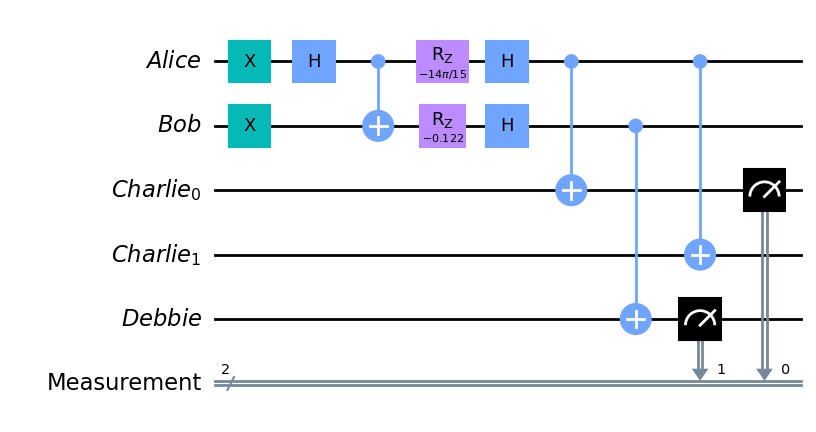

In [10]:
qc = ewfs(PEEK, PEEK, ANGLES, BETA, charlie_size=2)
qc.draw("mpl",style="clifford")

/Users/vrusso/Projects/research/wigners_friend/venv/lib/python3.11/site-packages/qiskit/visualization/circuit/matplotlib.py:266: FutureWarning: The default matplotlib drawer scheme will be changed to "iqp" in a following release. To silence this warning, specify the current default explicitly as style="clifford", or the new default as style="iqp".
  self._style, def_font_ratio = load_style(self._style)


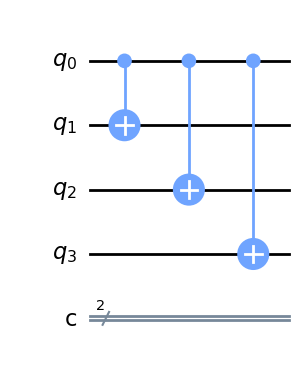

In [11]:
circuit = QuantumCircuit(4, 2)
cnot_ladder(circuit, 0, 1, 3)
circuit.draw("mpl")

## Experiments

In [15]:
def run_experiment(
    backend: Backend,
    noise_model: NoiseModel,
    friend_sizes: list[int],
    shots: float,
    verbose: bool = True,
    num_trials: int = 1
):
    all_results = {
        fs: {inequality: [] for inequality in ["semi_brukner"]}
        for fs in friend_sizes
    }
    for friend_size in friend_sizes:
        print(f"{friend_size=}")
        for _ in range(num_trials):
            results = generate_all_experiments(            
                backend=backend,
                noise_model=noise_model,
                shots=shots,
                angles=ANGLES,
                beta=BETA,
                charlie_size=friend_size,
            )
            violations = compute_inequalities(results, verbose=verbose)
            for key in violations:
                all_results[friend_size][key].append(violations[key])

    return all_results

## Plotting

In [16]:
def plot_results(
    ax,
    results: dict, 
    friend_sizes: list[int], 
    plot_title: str,
    plot_error_bars: bool = False, 
):
    # Compute averages and standard deviations
    avg_results = {}
    std_results = {}
    for fs in results:
        avg_results[fs] = {}
        std_results[fs] = {}
        for key in results[fs]:
            avg_results[fs][key] = np.mean(results[fs][key])
            if plot_error_bars:
                std_results[fs][key] = np.std(results[fs][key])

    # Plotting    
    markers = ["*"]
    colors = ["tab:blue"]
    titles = ["Semi-Brukner"]

    for i, key in enumerate(["semi_brukner"]):
        means = [np.mean(results[fs][key]) for fs in friend_sizes]
        errors = [np.std(results[fs][key]) for fs in friend_sizes] if plot_error_bars else None
        ax.errorbar(friend_sizes, means, yerr=errors, label=titles[i], fmt=markers[i], color=colors[i], capsize=5)

    ax.axhline(0, color="red", linestyle="dashed")
    ax.set_xticks(friend_sizes)
    ax.set_title(plot_title)
    ax.grid(True)

In [17]:
# Parameters for all plots
friend_sizes = range(1, 7)
num_trials = 1
shots = 10_000
backend = qiskit.Aer.get_backend("aer_simulator")

# Ideal simulator data
noise_model = None
simulator_results = run_experiment(
    backend=backend,
    noise_model=noise_model,
    friend_sizes=friend_sizes,
    num_trials=num_trials,
    shots=shots,    
    verbose=True,
)

friend_size=1
semi_brukner=0.3602000000000003 -- is violated: True
friend_size=2
semi_brukner=0.3541999999999996 -- is violated: True
friend_size=3
semi_brukner=0.4057999999999997 -- is violated: True
friend_size=4
semi_brukner=0.3894000000000002 -- is violated: True
friend_size=5
semi_brukner=0.3757999999999999 -- is violated: True
friend_size=6
semi_brukner=0.37319999999999975 -- is violated: True
